Лабораторна робота 3
"Кластеризація" 
Стецюк Максим КН-42 

Мета роботи: Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv("SpotifyFeatures.csv")
print()
print("Статистики числових колонок:")
df.describe().T


Статистики числових колонок:


,count,mean,std,min,25%,50%,75%,max
popularity,232725.0,41.127502,18.189948,0.00000,29.0000,43.000000,55.0000,100.000
acousticness,232725.0,0.368560,0.354768,0.00000,0.0376,0.232000,0.7220,0.996
danceability,232725.0,0.554364,0.185608,0.05690,0.4350,0.571000,0.6920,0.989
duration_ms,232725.0,235122.339306,118935.909299,15387.00000,182857.0000,220427.000000,265768.0000,5552917.000
energy,232725.0,0.570958,0.263456,0.00002,0.3850,0.605000,0.7870,0.999
instrumentalness,232725.0,0.148301,0.302768,0.00000,0.0000,0.000044,0.0358,0.999
liveness,232725.0,0.215009,0.198273,0.00967,0.0974,0.128000,0.2640,1.000
loudness,232725.0,-9.569885,5.998204,-52.45700,-11.7710,-7.762000,-5.5010,3.744
speechiness,232725.0,0.120765,0.185518,0.02220,0.0367,0.050100,0.1050,0.967
tempo,232725.0,117.666585,30.898907,30.37900,92.9590,115.778000,139.0540,242.903


Бачимо основні статистики числових ознак. Це дає змогу побачити діапазони значень, середні значення та можливі відхилення між ознаками, які надалі потрібно врахувати під час стандартизації.

In [43]:
feature_candidates = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo"
]

features = [col for col in feature_candidates if col in df.columns]
filtered_df = df[df["popularity"] >= 85].copy()
filtered_df = filtered_df[features].dropna().reset_index(drop=True)

print("Ознаки для кластеризації:")
print(features)
print("Розмір таблиці після видалення пропусків:", filtered_df.shape)

X_scaled = scaler.fit_transform(filtered_df[features])
clusters = kmeans.fit_predict(X_scaled)
print("Розмірність таблиці після фільтрації:", filtered_df.shape)
filtered_df.head()

Ознаки для кластеризації:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Розмір таблиці після видалення пропусків: (417, 9)
Розмірність таблиці після фільтрації: (417, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.726,0.554,-5.290,0.0917,0.0421,0.000000,0.1060,0.335,169.999
1,0.725,0.321,-10.744,0.3230,0.5780,0.000000,0.0884,0.319,70.142
2,0.752,0.488,-7.050,0.0705,0.2970,0.000009,0.0936,0.533,136.041
3,0.647,0.309,-7.948,0.0366,0.7800,0.000007,0.2020,0.195,87.045
4,0.747,0.458,-6.891,0.3030,0.4510,0.000000,0.2520,0.470,75.029


Було вибрано основні числові аудіо-ознаки, видалено рядки з пропусками та виконано стандартизацію, щоб усі ознаки мали співставний масштаб. Окремо сформовано вибірку популярних треків з popularity >= 85 для подальшої візуалізації.

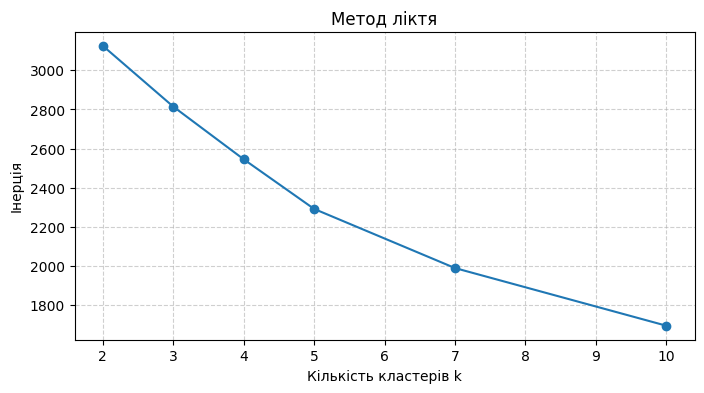

Оптимальне значення k: 7


In [44]:
k_values = [2, 3, 4, 5, 7, 10]
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Метод ліктя")
plt.xlabel("Кількість кластерів k")
plt.ylabel("Інерція")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
drops = np.diff(inertias)
drop_change = np.diff(drops)
elbow_index = np.argmin(drop_change) + 2
optimal_k = k_values[elbow_index]
print("Оптимальне значення k:", optimal_k)

Для підбору оптимальної кількості кластерів було використано метод ліктя. Для значень k від 2 до 10 обчислено інерцію, побудовано графік її залежності від кількості кластерів. Точка, де зменшення інерції починає сповільнюватися, приймається як оптимальне значення k.

In [52]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
clustered_df = filtered_df.copy()
clustered_df["cluster"] = clusters
print("Кількість треків у кожному кластері:")
print(clustered_df["cluster"].value_counts().sort_index())
clustered_df.head()

Кількість треків у кожному кластері:
cluster
0     33
1    103
2    101
3     64
4     66
5     49
6      1
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
0,0.726,0.554,-5.290,0.0917,0.0421,0.000000,0.1060,0.335,169.999,2
1,0.725,0.321,-10.744,0.3230,0.5780,0.000000,0.0884,0.319,70.142,3
2,0.752,0.488,-7.050,0.0705,0.2970,0.000009,0.0936,0.533,136.041,3
3,0.647,0.309,-7.948,0.0366,0.7800,0.000007,0.2020,0.195,87.045,3
4,0.747,0.458,-6.891,0.3030,0.4510,0.000000,0.2520,0.470,75.029,3


Вибрали оптимальне значення k та виконали кластеризацію за допомогою K-Means. Нова колонка cluster містить номер кластера для кожного треку та виведено кількість об'єктів у кожному кластері.

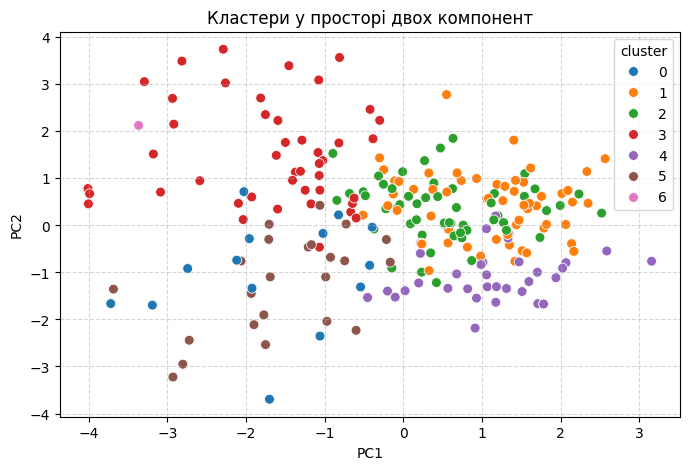

Частка поясненої дисперсії:  0.4088515508949959


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster,PC1,PC2
0,0.726,0.554,-5.290,0.0917,0.0421,0.000000,0.1060,0.335,169.999,2,0.347819,-0.585369
1,0.725,0.321,-10.744,0.3230,0.5780,0.000000,0.0884,0.319,70.142,3,-4.007634,0.784581
2,0.752,0.488,-7.050,0.0705,0.2970,0.000009,0.0936,0.533,136.041,3,-0.667384,0.284897
3,0.647,0.309,-7.948,0.0366,0.7800,0.000007,0.2020,0.195,87.045,3,-2.933009,2.701021
4,0.747,0.458,-6.891,0.3030,0.4510,0.000000,0.2520,0.470,75.029,3,-2.034763,0.124554


In [53]:
popular_scaled = scaler.transform(clustered_df[features])

pca_2d = PCA(n_components=2, random_state=42)
popular_2d = pca_2d.fit_transform(popular_scaled)

popular_plot_df = clustered_df.copy()
popular_plot_df["PC1"] = popular_2d[:, 0]
popular_plot_df["PC2"] = popular_2d[:, 1]
popular_plot_df["cluster"] = kmeans.predict(popular_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=popular_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=50
)
plt.title("Кластери у просторі двох компонент")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Частка поясненої дисперсії: ", pca_2d.explained_variance_ratio_.sum())
popular_plot_df.head()

Для візуалізації кластерів застосували PCA до двох компонент. На графіку бачимо треки з popularity >= 85, а колір точки відповідає номеру кластера. Таким чином бачимо х відокремленність.

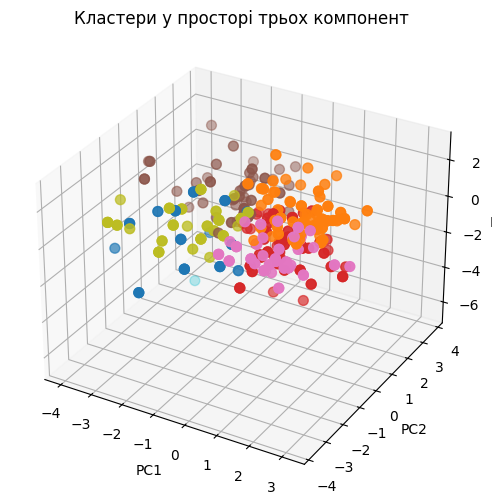

Частка поясненої дисперсії (3D):  0.5426218326405893


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster,PC1,PC2,PC1_3d,PC2_3d,PC3_3d
0,0.726,0.554,-5.290,0.0917,0.0421,0.000000,0.1060,0.335,169.999,2,0.347819,-0.585369,0.347819,-0.585369,-1.008792
1,0.725,0.321,-10.744,0.3230,0.5780,0.000000,0.0884,0.319,70.142,3,-4.007634,0.784581,-4.007634,0.784581,1.068508
2,0.752,0.488,-7.050,0.0705,0.2970,0.000009,0.0936,0.533,136.041,3,-0.667384,0.284897,-0.667384,0.284897,0.434988
3,0.647,0.309,-7.948,0.0366,0.7800,0.000007,0.2020,0.195,87.045,3,-2.933009,2.701021,-2.933009,2.701021,-0.065393
4,0.747,0.458,-6.891,0.3030,0.4510,0.000000,0.2520,0.470,75.029,3,-2.034763,0.124554,-2.034763,0.124554,0.898547


In [54]:
pca_3d = PCA(n_components=3, random_state=42)
popular_3d = pca_3d.fit_transform(popular_scaled)
popular_plot_df["PC1_3d"] = popular_3d[:, 0]
popular_plot_df["PC2_3d"] = popular_3d[:, 1]
popular_plot_df["PC3_3d"] = popular_3d[:, 2]
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    popular_plot_df["PC1_3d"],
    popular_plot_df["PC2_3d"],
    popular_plot_df["PC3_3d"],
    c=popular_plot_df["cluster"],
    cmap="tab10",
    s=50
)
ax.set_title("Кластери у просторі трьох компонент")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()
print("Частка поясненої дисперсії (3D): ", pca_3d.explained_variance_ratio_.sum())
popular_plot_df.head()

In [55]:
cluster_means = clustered_df.groupby("cluster")[features].mean()
cluster_means

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.830788,0.510606,-8.314364,0.164397,0.197927,0.002353,0.419061,0.457818,113.243212
1,0.727553,0.747146,-4.329320,0.098569,0.239966,0.000557,0.120381,0.616369,101.577146
2,0.635990,0.673644,-5.387911,0.073370,0.114454,0.001850,0.189832,0.339482,129.283772
3,0.643906,0.467234,-7.779844,0.132441,0.550562,0.002499,0.147783,0.393986,107.929469
4,0.744318,0.702985,-5.335894,0.153424,0.072340,0.001765,0.162559,0.636197,159.288152
5,0.886102,0.512469,-7.868776,0.245520,0.095222,0.005040,0.110235,0.383306,112.791122
6,0.596000,0.552000,-10.278000,0.097000,0.076500,0.334000,0.104000,0.112000,97.949000


Для аналізу кластерів обчислили середні значення основних ознак у кожному кластері. Ці значення дозволяють описати типові властивості треків усередині кожної групи.

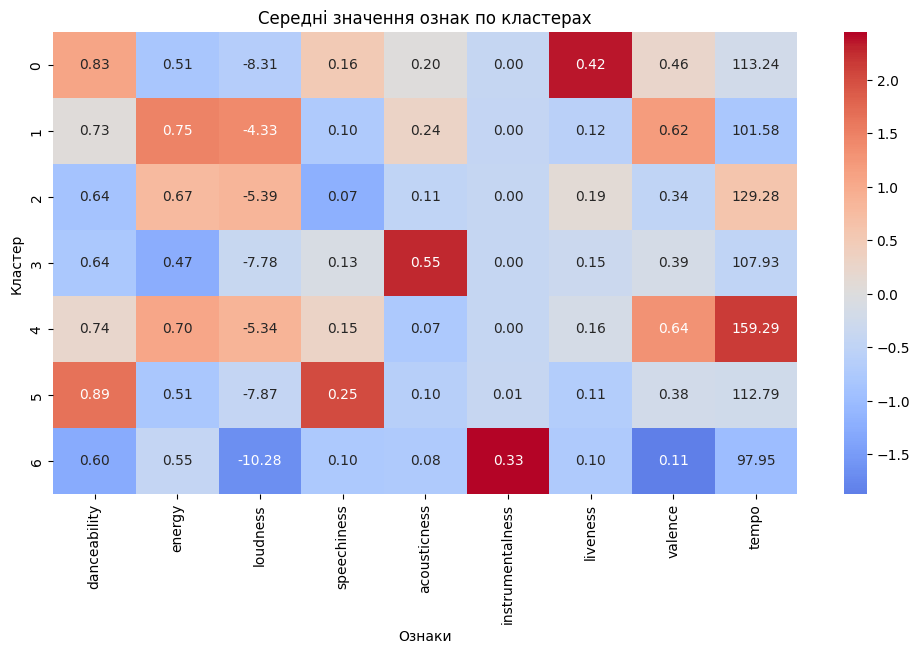

In [56]:
scaler_heatmap = StandardScaler()
cluster_means_z = pd.DataFrame(
    scaler_heatmap.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_z, annot=cluster_means, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Середні значення ознак по кластерах")
plt.xlabel("Ознаки")
plt.ylabel("Кластер")
plt.show()

За допомогою теплової карти можемо порівняти кластери між собою та добре видно, які групи мають вищу енергійність, темп, акустичність, інструментальність або інші характеристики.

In [57]:
interpretations = []
for cluster_id, row in cluster_means.iterrows():
    parts = []
    if "energy" in row.index:
        if row["energy"] >= cluster_means["energy"].median():
            parts.append("енергійні")
        else:
            parts.append("спокійні")
    if "danceability" in row.index:
        if row["danceability"] >= cluster_means["danceability"].median():
            parts.append("танцювальні")
        else:
            parts.append("менш танцювальні")
    if "acousticness" in row.index:
        if row["acousticness"] >= cluster_means["acousticness"].median():
            parts.append("акустичні")
        else:
            parts.append("менш акустичні")
    if "instrumentalness" in row.index and row["instrumentalness"] >= cluster_means["instrumentalness"].median():
        parts.append("інструментальні")
    if "tempo" in row.index and row["tempo"] >= cluster_means["tempo"].median():
        parts.append("вищий темп")
    interpretations.append(
        f"Кластер {cluster_id}: " + ", ".join(parts) + "."
    )
for text in interpretations:
    print(text)

Кластер 0: спокійні, танцювальні, акустичні, інструментальні, вищий темп.
Кластер 1: енергійні, танцювальні, акустичні.
Кластер 2: енергійні, менш танцювальні, акустичні, вищий темп.
Кластер 3: спокійні, менш танцювальні, акустичні, інструментальні.
Кластер 4: енергійні, танцювальні, менш акустичні, вищий темп.
Кластер 5: спокійні, танцювальні, менш акустичні, інструментальні, вищий темп.
Кластер 6: енергійні, менш танцювальні, менш акустичні, інструментальні.


За середніми значеннями ознак ми змогли інтерпретувати кластери. Наприклад один кластер може об'єднувати енергійні та танцювальні треки з вищим темпом, а інший же спокійні та акустичні композиції або треки з вираженим інструменталом.

У лабораторній роботі виконав кластеризацію треків зі Spotify за їх числовими аудіо-ознаками. Застосовано метод K-Means, отримано мітки кластерів та проаналізовано розподіл треків між ними.
Для графіку використано PCA. Побудовали таблицю середніх значень і теплову карту ознак для кластерів. Результати демонструють, що навіть без наперед заданих міток можна знайти природні групи треків з похожими музичними характеристиками, а кластеризація зручна для сегментації музичного контенту та аналізу.